In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score

# 1. Dataset Load Karna
df = sns.load_dataset('titanic')

# 2. Key Features Selection & Basic Preprocessing
# Target variable: 'survived'
features = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
X = df[features].copy()
y = df['survived']

# Missing values fill karna
X['age'] = X['age'].fillna(X['age'].median())
X['fare'] = X['fare'].fillna(X['fare'].median())
X['embarked'] = X['embarked'].fillna(X['embarked'].mode()[0])

# Categorical Data ko Numbers me convert karna
X = pd.get_dummies(X, columns=['sex', 'embarked'], drop_first=True)

# 3. Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Default Decision Tree (No Parameters Tuned)
dt_default = DecisionTreeClassifier(random_state=42)
dt_default.fit(X_train, y_train)

# 5. Model Evaluation
y_train_pred = dt_default.predict(X_train)
y_test_pred = dt_default.predict(X_test)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"Default Tree Depth: {dt_default.get_depth()}")
print(f"Default Tree Leaves: {dt_default.get_n_leaves()}")
print(f"Train Accuracy: {train_acc * 100:.2f}%")
print(f"Test Accuracy:  {test_acc * 100:.2f}%")

Default Tree Depth: 21
Default Tree Leaves: 180
Train Accuracy: 97.89%
Test Accuracy:  78.21%


--- Depth = 3 Model ---
Train Accuracy: 86.66%
Test Accuracy:  80.45%

--- Tree Logic Rules (depth=3) ---
|--- sex_male <= 0.50
|   |--- pclass <= 2.50
|   |   |--- age <= 2.50
|   |   |   |--- fare <= 88.78
|   |   |   |   |--- class: 1
|   |   |   |--- fare >  88.78
|   |   |   |   |--- class: 0
|   |   |--- age >  2.50
|   |   |   |--- age <= 27.50
|   |   |   |   |--- age <= 24.50
|   |   |   |   |   |--- fare <= 13.40
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- fare >  13.40
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |--- age >  24.50
|   |   |   |   |   |--- parch <= 1.50
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- parch >  1.50
|   |   |   |   |   |   |--- class: 0
|   |   |   |--- age >  27.50
|   |   |   |   |--- age <= 49.50
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- age >  49.50
|   |   |   |   |   |--- age <= 50.50
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- age >  50.50
|   |   |   |   |   |   

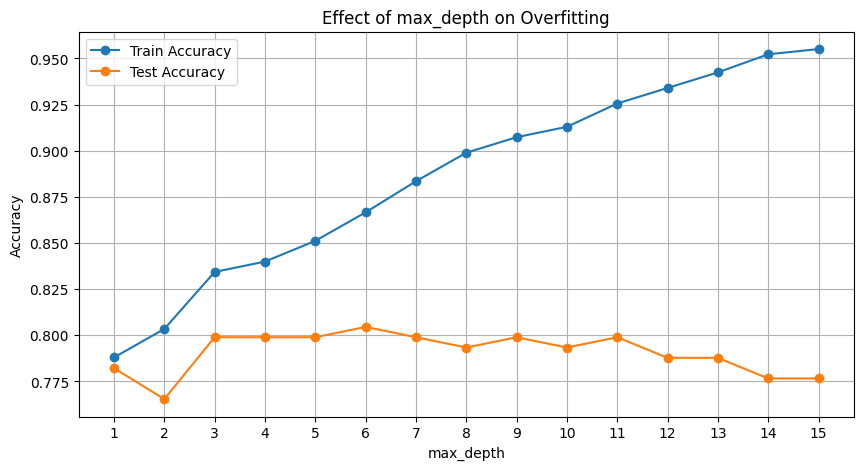

In [4]:
# Part A: max_depth=3 se Model Train aur Visualize Karna
dt_depth3 = DecisionTreeClassifier(max_depth=6, random_state=42)
dt_depth3.fit(X_train, y_train)

train_acc_3 = accuracy_score(y_train, dt_depth3.predict(X_train))
test_acc_3 = accuracy_score(y_test, dt_depth3.predict(X_test))

print(f"--- Depth = 3 Model ---")
print(f"Train Accuracy: {train_acc_3 * 100:.2f}%")
print(f"Test Accuracy:  {test_acc_3 * 100:.2f}%")

# Tree Decision Logic View (Text Format)
print("\n--- Tree Logic Rules (depth=3) ---")
print(export_text(dt_depth3, feature_names=list(X.columns)))

# Part B: Depth 1 se 15 Tak Ka Comparison Graph
train_scores = []
test_scores = []
depths = range(1, 16)

for depth in depths:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, dt.predict(X_train)))
    test_scores.append(accuracy_score(y_test, dt.predict(X_test)))

# Graph Plotting
plt.figure(figsize=(10, 5))
plt.plot(depths, train_scores, label='Train Accuracy', marker='o')
plt.plot(depths, test_scores, label='Test Accuracy', marker='o')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Effect of max_depth on Overfitting')
plt.xticks(depths)
plt.legend()
plt.grid(True)
plt.show()

🛠️ Step 3: Node Control - Tuning min_samples_split & min_samples_leaf
Ab hum agle do most important pruning hyperparameters ko evaluate karenge:

min_samples_split: Parent node par minimum kitne samples hone chahiye split start karne ke liye.

min_samples_leaf: Split ke baad banne wali har Leaf par minimum kitne samples hone chahiye.

Hum dekhenge ki kya inko set karke hum generalization ko aur improve kar sakte hain.

Apni Notebook me yeh code run kijiye:

In [5]:
# Part A: min_samples_split ka Effect Check Karna (Depth set to 6)
splits = [2, 5, 10, 20, 50, 100]
split_test_acc = []

for split in splits:
    dt = DecisionTreeClassifier(max_depth=6, min_samples_split=split, random_state=42)
    dt.fit(X_train, y_train)
    split_test_acc.append(accuracy_score(y_test, dt.predict(X_test)))

print("--- Effect of min_samples_split (at depth=6) ---")
for s, acc in zip(splits, split_test_acc):
    print(f"min_samples_split = {s:<3} --> Test Accuracy: {acc * 100:.2f}%")

print("\n" + "="*45 + "\n")

# Part B: min_samples_leaf ka Effect Check Karna
leaves = [1, 2, 5, 10, 20, 50]
leaf_test_acc = []

for leaf in leaves:
    dt = DecisionTreeClassifier(max_depth=6, min_samples_leaf=leaf, random_state=42)
    dt.fit(X_train, y_train)
    leaf_test_acc.append(accuracy_score(y_test, dt.predict(X_test)))

print("--- Effect of min_samples_leaf (at depth=6) ---")
for l, acc in zip(leaves, leaf_test_acc):
    print(f"min_samples_leaf = {l:<3} --> Test Accuracy: {acc * 100:.2f}%")

--- Effect of min_samples_split (at depth=6) ---
min_samples_split = 2   --> Test Accuracy: 80.45%
min_samples_split = 5   --> Test Accuracy: 80.45%
min_samples_split = 10  --> Test Accuracy: 81.01%
min_samples_split = 20  --> Test Accuracy: 80.45%
min_samples_split = 50  --> Test Accuracy: 78.77%
min_samples_split = 100 --> Test Accuracy: 79.33%


--- Effect of min_samples_leaf (at depth=6) ---
min_samples_leaf = 1   --> Test Accuracy: 80.45%
min_samples_leaf = 2   --> Test Accuracy: 80.45%
min_samples_leaf = 5   --> Test Accuracy: 84.92%
min_samples_leaf = 10  --> Test Accuracy: 79.89%
min_samples_leaf = 20  --> Test Accuracy: 79.33%
min_samples_leaf = 50  --> Test Accuracy: 81.01%


#.4 🛠️ Step 4: Decision Criteria & Splitter Strategy (criterion & splitter)
Ab hum do aur important parameters evaluate karenge:

criterion: Impurity measure karne ka tarika — "gini" vs "entropy" / "log_loss".

splitter: Node split karne ki strategy — "best" (sabse best feature dhoondhna) vs "random" (random best split choose karna).

Hum check karenge ki humare optimized depth aur leaf parameters (max_depth=6, min_samples_leaf=5) ke saath kaunsa combination best perform karta hai.

In [6]:
# Part A: Criterion Compare Karna ('gini' vs 'entropy' vs 'log_loss')
criteria = ['gini', 'entropy', 'log_loss']
criterion_scores = []

for c in criteria:
    dt = DecisionTreeClassifier(
        criterion=c,
        max_depth=6,
        min_samples_leaf=5,
        random_state=42
    )
    dt.fit(X_train, y_train)
    acc = accuracy_score(y_test, dt.predict(X_test))
    criterion_scores.append(acc)

print("--- Effect of criterion ---")
for c, acc in zip(criteria, criterion_scores):
    print(f"criterion = '{c}' --> Test Accuracy: {acc * 100:.2f}%")

print("\n" + "="*45 + "\n")

# Part B: Splitter Compare Karna ('best' vs 'random')
splitters = ['best', 'random']
splitter_scores = []

for s in splitters:
    dt = DecisionTreeClassifier(
        splitter=s,
        max_depth=6,
        min_samples_leaf=5,
        random_state=42
    )
    dt.fit(X_train, y_train)
    acc = accuracy_score(y_test, dt.predict(X_test))
    splitter_scores.append(acc)

print("--- Effect of splitter ---")
for s, acc in zip(splitters, splitter_scores):
    print(f"splitter = '{s}' --> Test Accuracy: {acc * 100:.2f}%")

--- Effect of criterion ---
criterion = 'gini' --> Test Accuracy: 84.92%
criterion = 'entropy' --> Test Accuracy: 82.68%
criterion = 'log_loss' --> Test Accuracy: 82.68%


--- Effect of splitter ---
splitter = 'best' --> Test Accuracy: 84.92%
splitter = 'random' --> Test Accuracy: 79.33%


#5. 🛠️ Step 5: Feature Subsampling & Class Balancing (max_features & class_weight)
Ab hum do aur critical parameters ko check karenge:

max_features: Split karte waqt kitne features consider karne hain (e.g., None, 'sqrt', 'log2', ya fraction).

class_weight: Titanic dataset me survivors kam hain (imbalanced dataset), toh dekhte hain ki class_weight='balanced' lagane se performance par kya effect padta hai.

In [7]:
# Part A: max_features Compare Karna
max_feat_options = [None, 'sqrt', 'log2', 0.5, 0.7]
max_feat_scores = []

for mf in max_feat_options:
    dt = DecisionTreeClassifier(
        max_features=mf,
        max_depth=6,
        min_samples_leaf=5,
        criterion='gini',
        splitter='best',
        random_state=42
    )
    dt.fit(X_train, y_train)
    acc = accuracy_score(y_test, dt.predict(X_test))
    max_feat_scores.append(acc)

print("--- Effect of max_features ---")
for mf, acc in zip(max_feat_options, max_feat_scores):
    print(f"max_features = {str(mf):<6} --> Test Accuracy: {acc * 100:.2f}%")

print("\n" + "="*45 + "\n")

# Part B: class_weight Compare Karna (None vs 'balanced')
weights = [None, 'balanced']
weight_scores = []

for w in weights:
    dt = DecisionTreeClassifier(
        class_weight=w,
        max_depth=6,
        min_samples_leaf=5,
        criterion='gini',
        splitter='best',
        random_state=42
    )
    dt.fit(X_train, y_train)
    acc = accuracy_score(y_test, dt.predict(X_test))
    weight_scores.append(acc)

print("--- Effect of class_weight ---")
for w, acc in zip(weights, weight_scores):
    print(f"class_weight = {str(w):<8} --> Test Accuracy: {acc * 100:.2f}%")

--- Effect of max_features ---
max_features = None   --> Test Accuracy: 84.92%
max_features = sqrt   --> Test Accuracy: 80.45%
max_features = log2   --> Test Accuracy: 81.56%
max_features = 0.5    --> Test Accuracy: 81.01%
max_features = 0.7    --> Test Accuracy: 81.01%


--- Effect of class_weight ---
class_weight = None     --> Test Accuracy: 84.92%
class_weight = balanced --> Test Accuracy: 83.80%


#6. 🛠️ Step 6: Advanced & Final Pruning (min_impurity_decrease & ccp_alpha)

Yeh humara FINAL STEP hai! Isme hum do advanced parameters evaluate karenge:

min_impurity_decrease: Minimum Gain / Purity improvement threshold.

ccp_alpha (Cost-Complexity Pruning): Post-pruning technique jo poore grew tree ko trim karti hai.

Is step ke baad humara poora Decision Tree parameter landscape complete ho jayega!

In [8]:
# Part A: min_impurity_decrease Check Karna
impurity_values = [0.0, 0.001, 0.005, 0.01, 0.02, 0.05]
impurity_scores = []

for imp in impurity_values:
    dt = DecisionTreeClassifier(
        min_impurity_decrease=imp,
        max_depth=6,
        min_samples_leaf=5,
        random_state=42
    )
    dt.fit(X_train, y_train)
    acc = accuracy_score(y_test, dt.predict(X_test))
    impurity_scores.append(acc)

print("--- Effect of min_impurity_decrease ---")
for imp, acc in zip(impurity_values, impurity_scores):
    print(f"min_impurity_decrease = {imp:<5} --> Test Accuracy: {acc * 100:.2f}%")

print("\n" + "="*45 + "\n")

# Part B: Post Pruning using ccp_alpha
alphas = [0.0, 0.001, 0.005, 0.01, 0.02]
alpha_scores = []

for alpha in alphas:
    dt = DecisionTreeClassifier(
        ccp_alpha=alpha,
        random_state=42
    )
    dt.fit(X_train, y_train)
    acc = accuracy_score(y_test, dt.predict(X_test))
    alpha_scores.append(acc)

print("--- Effect of Cost-Complexity Pruning (ccp_alpha) ---")
for a, acc in zip(alphas, alpha_scores):
    print(f"ccp_alpha = {a:<5} --> Test Accuracy: {acc * 100:.2f}%")

--- Effect of min_impurity_decrease ---
min_impurity_decrease = 0.0   --> Test Accuracy: 84.92%
min_impurity_decrease = 0.001 --> Test Accuracy: 84.92%
min_impurity_decrease = 0.005 --> Test Accuracy: 79.89%
min_impurity_decrease = 0.01  --> Test Accuracy: 79.89%
min_impurity_decrease = 0.02  --> Test Accuracy: 76.54%
min_impurity_decrease = 0.05  --> Test Accuracy: 78.21%


--- Effect of Cost-Complexity Pruning (ccp_alpha) ---
ccp_alpha = 0.0   --> Test Accuracy: 78.21%
ccp_alpha = 0.001 --> Test Accuracy: 78.77%
ccp_alpha = 0.005 --> Test Accuracy: 79.89%
ccp_alpha = 0.01  --> Test Accuracy: 79.89%
ccp_alpha = 0.02  --> Test Accuracy: 76.54%
